# WF01 — Wildfire Active-Fire Data Inspection

## Objective
Inspect satellite-derived active-fire detections before developing a wildfire monitoring baseline.

## Research questions
1. What fields are available in the active-fire dataset?
2. Are coordinates, timestamps, and numeric attributes valid?
3. How are detections distributed geographically?
4. How do confidence, brightness, and fire radiative power vary?
5. What data limitations must be considered before modelling?

## Data source
NASA FIRMS — MODIS Collection 6.1 active-fire data.

## Important limitation
An active-fire detection represents a satellite-observed thermal anomaly. It does not independently confirm a wildfire or identify its cause.

## Experiment type
Data inspection and quality assessment only. No predictive model or accuracy claim is made in this experiment.

In [1]:
# Install only the libraries needed for this inspection.
!pip -q install pandas matplotlib seaborn

import os
import time
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

BASE_DIR = "/content/wildfire_monitoring"
DATA_DIR = os.path.join(BASE_DIR, "data")
RESULTS_DIR = os.path.join(BASE_DIR, "results")

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print("Base directory:", BASE_DIR)
print("Data directory:", DATA_DIR)
print("Results directory:", RESULTS_DIR)
print("Libraries imported successfully.")

Base directory: /content/wildfire_monitoring
Data directory: /content/wildfire_monitoring/data
Results directory: /content/wildfire_monitoring/results
Libraries imported successfully.


In [2]:
# NASA FIRMS public MODIS Collection 6.1 global 24-hour CSV.
DATA_URL = (
    "https://firms.modaps.eosdis.nasa.gov/"
    "data/active_fire/modis-c6.1/csv/"
    "MODIS_C6_1_Global_24h.csv"
)

CSV_PATH = os.path.join(DATA_DIR, "MODIS_C6_1_Global_24h.csv")

retrieved_at_utc = pd.Timestamp.now(tz="UTC").isoformat()

if not os.path.exists(CSV_PATH) or os.path.getsize(CSV_PATH) == 0:
    print("Downloading NASA FIRMS snapshot...")
    response = requests.get(DATA_URL, timeout=120)
    response.raise_for_status()

    if not response.text.strip():
        raise ValueError("The downloaded CSV is empty.")

    with open(CSV_PATH, "wb") as file:
        file.write(response.content)

print("Dataset path:", CSV_PATH)
print("File size (bytes):", os.path.getsize(CSV_PATH))
print("Retrieved at (UTC):", retrieved_at_utc)
print("Source URL:", DATA_URL)

Dataset path: /content/wildfire_monitoring/data/MODIS_C6_1_Global_24h.csv
File size (bytes): 1371235
Retrieved at (UTC): 2026-10-09T16:12:50.612561+00:00
Source URL: https://firms.modaps.eosdis.nasa.gov/data/active_fire/modis-c6.1/csv/MODIS_C6_1_Global_24h.csv


In [3]:
df = pd.read_csv(CSV_PATH)

if df.empty:
    raise ValueError("The CSV loaded successfully but contains no records.")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst five records:")
display(df.head())

print("\nData types:")
display(df.dtypes.to_frame("data_type"))

Rows: 17725
Columns: 13

Column names:
['latitude', 'longitude', 'brightness', 'scan', 'track', 'acq_date', 'acq_time', 'satellite', 'confidence', 'version', 'bright_t31', 'frp', 'daynight']

First five records:


,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,confidence,version,bright_t31,frp,daynight
0,8.00848,-62.21064,304.89,4.61,1.97,2026-10-08,1,T,62,6.1NRT,291.50,45.11,N
1,-0.61100,117.00425,310.01,1.00,1.00,2026-10-08,48,T,47,6.1NRT,294.66,5.20,D
2,-1.46182,121.22361,308.89,1.51,1.21,2026-10-08,48,T,68,6.1NRT,294.72,8.86,D
3,-1.04476,116.16832,307.77,1.03,1.01,2026-10-08,48,T,41,6.1NRT,296.10,4.12,D
4,-1.10710,116.15981,309.12,1.03,1.01,2026-10-08,48,T,41,6.1NRT,295.94,4.67,D



Data types:


,data_type
latitude,float64
longitude,float64
brightness,float64
scan,float64
track,float64
acq_date,object
acq_time,int64
satellite,object
confidence,int64
version,object


In [4]:
quality = pd.DataFrame({
    "data_type": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2),
    "unique_values": df.nunique(dropna=True)
})

print("Dataset quality summary:")
display(quality)

duplicate_count = int(df.duplicated().sum())
print("Exact duplicate rows:", duplicate_count)

quality.to_csv(
    os.path.join(RESULTS_DIR, "WF01_data_quality.csv"),
    index=True
)

print("Saved WF01_data_quality.csv")

Dataset quality summary:


,data_type,missing_count,missing_percent,unique_values
latitude,float64,0,0.0,17658
longitude,float64,0,0.0,17690
brightness,float64,0,0.0,4387
scan,float64,0,0.0,267
track,float64,0,0.0,101
acq_date,object,0,0.0,2
acq_time,int64,0,0.0,339
satellite,object,0,0.0,2
confidence,int64,0,0.0,101
version,object,0,0.0,1


Exact duplicate rows: 0
Saved WF01_data_quality.csv


In [5]:
# Check that the required coordinate columns exist.
required_columns = ["latitude", "longitude"]

missing_required = [
    column for column in required_columns
    if column not in df.columns
]

if missing_required:
    raise ValueError(
        f"Required columns missing from downloaded CSV: {missing_required}"
    )

# Convert coordinates to numeric values for validation.
df["latitude"] = pd.to_numeric(df["latitude"], errors="coerce")
df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")

valid_coordinates = (
    df["latitude"].between(-90, 90)
    & df["longitude"].between(-180, 180)
)

print("Total records:", len(df))
print("Valid coordinate records:", int(valid_coordinates.sum()))
print("Invalid or missing coordinate records:", int((~valid_coordinates).sum()))

for column in ["brightness", "confidence", "frp", "scan", "track"]:
    if column in df.columns:
        df[column] = pd.to_numeric(df[column], errors="coerce")
        print(f"\n{column} summary:")
        display(df[column].describe().to_frame())

# Save the inspected copy, preserving the original downloaded CSV.
df.to_csv(
    os.path.join(RESULTS_DIR, "WF01_inspected_data.csv"),
    index=False
)

Total records: 17725
Valid coordinate records: 17725
Invalid or missing coordinate records: 0

brightness summary:


,brightness
count,17725.000000
mean,321.872869
std,17.525580
min,300.000000
25%,311.860000
50%,318.240000
75%,326.160000
max,499.970000



confidence summary:


,confidence
count,17725.000000
mean,67.214838
std,20.675137
min,0.000000
25%,55.000000
50%,68.000000
75%,82.000000
max,100.000000



frp summary:


,frp
count,17725.000000
mean,32.307105
std,85.523966
min,0.000000
25%,8.440000
50%,14.390000
75%,28.110000
max,1968.150000



scan summary:


,scan
count,17725.000000
mean,1.419218
std,0.638662
min,1.000000
25%,1.040000
50%,1.160000
75%,1.530000
max,4.820000



track summary:


,track
count,17725.000000
mean,1.154063
std,0.197567
min,1.000000
25%,1.020000
50%,1.070000
75%,1.220000
max,2.000000


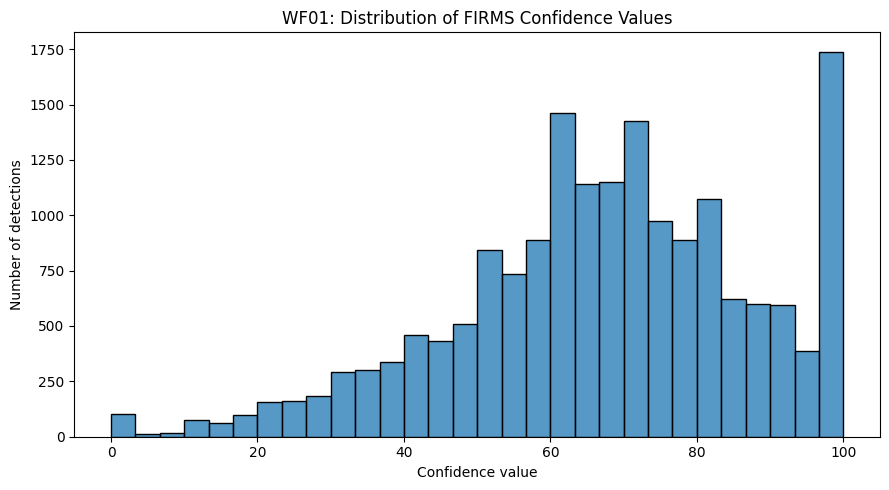

Saved: /content/wildfire_monitoring/results/WF01_confidence_distribution.png


In [6]:
if "confidence" in df.columns:
    confidence_values = df["confidence"].dropna()

    if len(confidence_values) > 0:
        plt.figure(figsize=(9, 5))
        sns.histplot(confidence_values, bins=30)
        plt.title("WF01: Distribution of FIRMS Confidence Values")
        plt.xlabel("Confidence value")
        plt.ylabel("Number of detections")
        plt.tight_layout()

        output_path = os.path.join(
            RESULTS_DIR, "WF01_confidence_distribution.png"
        )
        plt.savefig(output_path, dpi=150)
        plt.show()

        print("Saved:", output_path)
    else:
        print("Confidence column exists but has no usable values.")
else:
    print("Confidence field is not available in this dataset snapshot.")

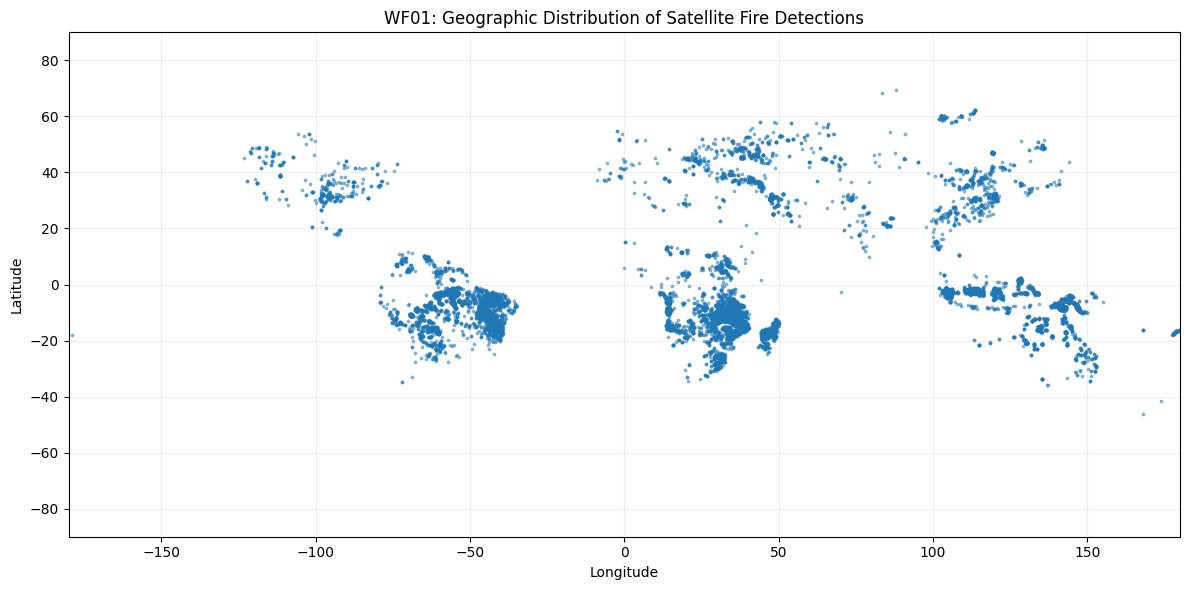

Records with valid coordinates: 17725
Points plotted: 15000
Saved: /content/wildfire_monitoring/results/WF01_global_detection_distribution.png


In [7]:
map_df = df.loc[
    df["latitude"].between(-90, 90)
    & df["longitude"].between(-180, 180)
].copy()

if map_df.empty:
    raise ValueError("No records with valid coordinates are available.")

# Sample only for faster plotting if the dataset is large.
plot_df = map_df.sample(
    n=min(15000, len(map_df)),
    random_state=42
)

plt.figure(figsize=(12, 6))
plt.scatter(
    plot_df["longitude"],
    plot_df["latitude"],
    s=3,
    alpha=0.45
)
plt.title("WF01: Geographic Distribution of Satellite Fire Detections")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.xlim(-180, 180)
plt.ylim(-90, 90)
plt.grid(alpha=0.2)
plt.tight_layout()

output_path = os.path.join(
    RESULTS_DIR, "WF01_global_detection_distribution.png"
)
plt.savefig(output_path, dpi=150)
plt.show()

print("Records with valid coordinates:", len(map_df))
print("Points plotted:", len(plot_df))
print("Saved:", output_path)

In [8]:
# ============================================================
# CELL 9 — ACQUISITION DATE AND TIME INSPECTION
# ============================================================
# Why this cell matters:
# Satellite observations are time-dependent. We need to know when
# detections occurred before comparing them with weather or other data.
#
# NASA FIRMS commonly provides:
#   acq_date : acquisition date, such as 2026-10-09
#   acq_time : acquisition time in HHMM format, such as 0430
#
# We check the columns first so that missing fields produce a clear
# message instead of an unexplained KeyError.

required_time_columns = ["acq_date", "acq_time"]

missing_time_columns = [
    column for column in required_time_columns
    if column not in df.columns
]

if missing_time_columns:
    raise ValueError(
        "Cannot build acquisition timestamps. Missing columns: "
        f"{missing_time_columns}. Available columns: {df.columns.tolist()}"
    )

# Convert dates and times into consistent strings.
# zfill(4) preserves times such as 0035, which would otherwise become 35.
date_text = df["acq_date"].astype("string").str.strip()
time_text = (
    pd.to_numeric(df["acq_time"], errors="coerce")
    .round()
    .astype("Int64")
    .astype("string")
    .str.zfill(4)
)

# Parse date and time separately, then combine them.
parsed_date = pd.to_datetime(date_text, errors="coerce")
valid_time_format = time_text.str.fullmatch(r"\d{4}", na=False)

parsed_time = pd.to_datetime(
    time_text.where(valid_time_format),
    format="%H%M",
    errors="coerce"
)

# Build a timestamp only when both the date and time are valid.
df["acquisition_datetime"] = (
    parsed_date.dt.strftime("%Y-%m-%d").astype("string")
    + " "
    + parsed_time.dt.strftime("%H:%M:%S").astype("string")
)

df["acquisition_datetime"] = pd.to_datetime(
    df["acquisition_datetime"],
    errors="coerce"
)

valid_timestamps = df["acquisition_datetime"].dropna()

print("Total records:", len(df))
print("Valid acquisition timestamps:", len(valid_timestamps))
print("Invalid or missing timestamps:", df["acquisition_datetime"].isna().sum())

if len(valid_timestamps) > 0:
    print("Earliest timestamp:", valid_timestamps.min())
    print("Latest timestamp:", valid_timestamps.max())

    # Count observations by acquisition date.
    daily_counts = (
        valid_timestamps.dt.date
        .value_counts()
        .sort_index()
        .rename_axis("acquisition_date")
        .reset_index(name="detection_count")
    )

    # Save the daily counts for the experiment report.
    daily_counts.to_csv(
        os.path.join(RESULTS_DIR, "WF01_daily_detection_counts.csv"),
        index=False
    )

    display(daily_counts.head(10))
    print("Saved WF01_daily_detection_counts.csv")
else:
    print("No valid timestamps were available for date-wise analysis.")

Total records: 17725
Valid acquisition timestamps: 17725
Invalid or missing timestamps: 0
Earliest timestamp: 2026-10-08 00:01:00
Latest timestamp: 2026-10-09 14:33:00


,acquisition_date,detection_count
0,2026-10-08,11518
1,2026-10-09,6207


Saved WF01_daily_detection_counts.csv


,daynight_category,detection_count
0,D,13097
1,N,4628


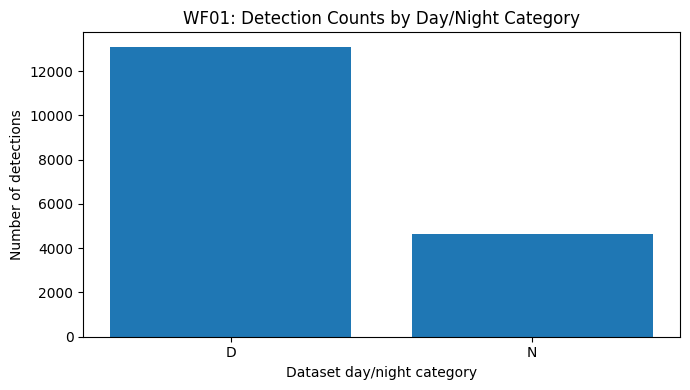

Saved WF01_daynight_counts.csv
Saved WF01_daynight_distribution.png


In [9]:
# ============================================================
# CELL 10 — DAY/NIGHT ATTRIBUTE INSPECTION
# ============================================================
# Why this cell matters:
# The daynight field records the product's day/night classification.
# We inspect the actual values instead of assuming they are always
# encoded as D/N or that every row has a value.

if "daynight" in df.columns:
    # Normalize text so that values such as "d" and "D" are grouped.
    daynight_values = (
        df["daynight"]
        .astype("string")
        .str.strip()
        .str.upper()
        .fillna("MISSING")
    )

    # Count every observed category, including missing values.
    daynight_counts = (
        daynight_values
        .value_counts(dropna=False)
        .rename_axis("daynight_category")
        .reset_index(name="detection_count")
    )

    display(daynight_counts)

    # Save the table for reproducibility.
    daynight_counts.to_csv(
        os.path.join(RESULTS_DIR, "WF01_daynight_counts.csv"),
        index=False
    )

    # Plot the observed categories.
    plt.figure(figsize=(7, 4))
    plt.bar(
        daynight_counts["daynight_category"].astype(str),
        daynight_counts["detection_count"]
    )
    plt.title("WF01: Detection Counts by Day/Night Category")
    plt.xlabel("Dataset day/night category")
    plt.ylabel("Number of detections")
    plt.tight_layout()

    figure_path = os.path.join(
        RESULTS_DIR, "WF01_daynight_distribution.png"
    )
    plt.savefig(figure_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("Saved WF01_daynight_counts.csv")
    print("Saved WF01_daynight_distribution.png")
else:
    # Continue the inspection without fabricating a day/night field.
    print("The daynight column is not available in this CSV.")
    print("Day/night analysis was skipped for this dataset snapshot.")

In [10]:
# ============================================================
# CELL 11 — FIRE-RELATED ATTRIBUTE SUMMARY
# ============================================================
# Why this cell matters:
# Brightness temperatures and fire radiative power describe different
# properties. We must not treat them as interchangeable or assume that
# a high value alone confirms a wildfire.
#
# Possible MODIS fields:
#   bright_ti4 : brightness temperature for the MODIS 4-micrometre band
#   bright_ti5 : brightness temperature for the MODIS 11-micrometre band
#   frp        : fire radiative power, commonly expressed in MW
#   confidence : product-specific detection confidence
#   scan/track : approximate observation footprint dimensions

candidate_numeric_fields = [
    "bright_ti4",
    "bright_ti5",
    "brightness",
    "frp",
    "confidence",
    "scan",
    "track"
]

# Only inspect columns that actually exist in the downloaded file.
available_numeric_fields = [
    column for column in candidate_numeric_fields
    if column in df.columns
]

if not available_numeric_fields:
    print("No recognized fire-related numeric fields were found.")
else:
    # Convert available fields to numeric; unparseable values become NaN.
    for column in available_numeric_fields:
        df[column] = pd.to_numeric(df[column], errors="coerce")

    # Generate descriptive statistics for each available field.
    numeric_summary = df[available_numeric_fields].describe().T

    # Add counts of missing values and negative values for quality review.
    numeric_summary["missing_count"] = (
        df[available_numeric_fields].isna().sum()
    )
    numeric_summary["negative_count"] = (
        df[available_numeric_fields].lt(0).sum()
    )

    display(numeric_summary.round(3))

    # Save a table that can be referenced by the WF01 report.
    numeric_summary.to_csv(
        os.path.join(RESULTS_DIR, "WF01_numeric_attribute_summary.csv")
    )

    print("Saved WF01_numeric_attribute_summary.csv")

# Report whether common MODIS columns were present.
print("\nRecognized fields found:")
for column in candidate_numeric_fields:
    print(f"{column}: {'present' if column in df.columns else 'not present'}")

,count,mean,std,min,25%,50%,75%,max,missing_count,negative_count
brightness,17725.0,321.873,17.526,300.0,311.86,318.24,326.16,499.97,0,0
frp,17725.0,32.307,85.524,0.0,8.44,14.39,28.11,1968.15,0,0
confidence,17725.0,67.215,20.675,0.0,55.00,68.00,82.00,100.00,0,0
scan,17725.0,1.419,0.639,1.0,1.04,1.16,1.53,4.82,0,0
track,17725.0,1.154,0.198,1.0,1.02,1.07,1.22,2.00,0,0


Saved WF01_numeric_attribute_summary.csv

Recognized fields found:
bright_ti4: not present
bright_ti5: not present
brightness: present
frp: present
confidence: present
scan: present
track: present


,latitude_group,longitude_group,detection_count,percentage_of_valid_coordinates
2,Southern Hemisphere,Eastern Hemisphere,9705,54.75
3,Southern Hemisphere,Western Hemisphere,4543,25.63
0,Northern Hemisphere,Eastern Hemisphere,2796,15.77
1,Northern Hemisphere,Western Hemisphere,681,3.84


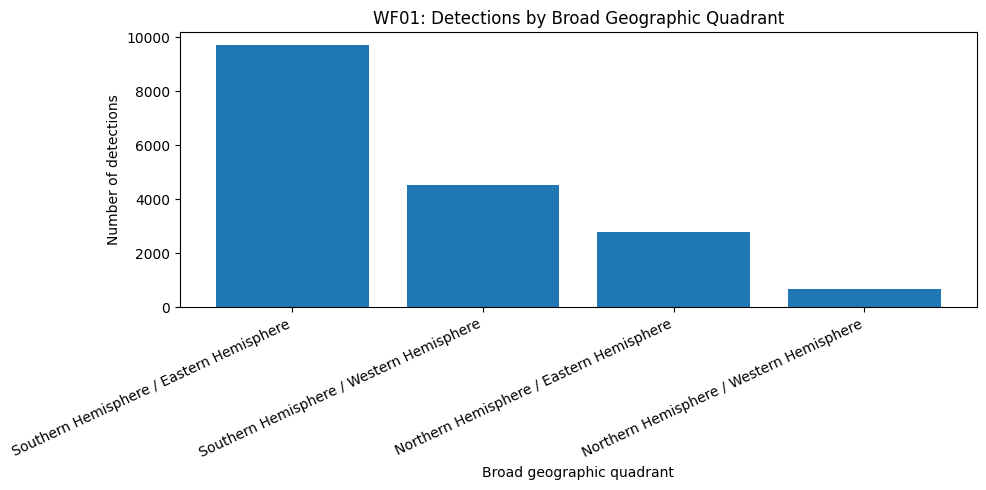

Saved WF01_geographic_summary.csv
Saved WF01_geographic_summary.png


In [11]:
# ============================================================
# CELL 12 — BROAD GEOGRAPHIC DISTRIBUTION SUMMARY
# ============================================================
# Why this cell matters:
# A global detection dataset can contain observations from many regions.
# Broad geographic summaries help us understand where records occur.
#
# IMPORTANT:
# These labels are coarse geographic groups, not country boundaries,
# fire-perimeter maps, or estimates of burned area.

# Use only records whose coordinates fall within valid geographic ranges.
geo_df = df.loc[
    df["latitude"].between(-90, 90)
    & df["longitude"].between(-180, 180)
].copy()

if geo_df.empty:
    raise ValueError("No valid coordinates are available for geographic analysis.")

# Assign each observation to one of four broad geographic quadrants.
# Latitude 0 and longitude 0 are assigned to the northern/eastern groups.
geo_df["latitude_group"] = np.where(
    geo_df["latitude"] >= 0, "Northern Hemisphere", "Southern Hemisphere"
)

geo_df["longitude_group"] = np.where(
    geo_df["longitude"] >= 0, "Eastern Hemisphere", "Western Hemisphere"
)

# Count records in each combination of hemispheres.
regional_summary = (
    geo_df.groupby(
        ["latitude_group", "longitude_group"],
        observed=True
    )
    .size()
    .reset_index(name="detection_count")
    .sort_values("detection_count", ascending=False)
)

# Calculate each group's share of all records with valid coordinates.
regional_summary["percentage_of_valid_coordinates"] = (
    regional_summary["detection_count"] / len(geo_df) * 100
).round(2)

display(regional_summary)

# Save the table so the experiment report can use actual values.
regional_summary.to_csv(
    os.path.join(RESULTS_DIR, "WF01_geographic_summary.csv"),
    index=False
)

# Plot the four broad geographic groups.
regional_summary["region_label"] = (
    regional_summary["latitude_group"]
    + " / "
    + regional_summary["longitude_group"]
)

plt.figure(figsize=(10, 5))
plt.bar(
    regional_summary["region_label"],
    regional_summary["detection_count"]
)
plt.title("WF01: Detections by Broad Geographic Quadrant")
plt.xlabel("Broad geographic quadrant")
plt.ylabel("Number of detections")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()

figure_path = os.path.join(
    RESULTS_DIR, "WF01_geographic_summary.png"
)
plt.savefig(figure_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved WF01_geographic_summary.csv")
print("Saved WF01_geographic_summary.png")

In [12]:
# ============================================================
# CELL 13 — GENERATE THE WF01 EXPERIMENT SUMMARY
# ============================================================
# Why this cell matters:
# Research experiments need a reproducible record of what was inspected.
# This summary uses values from the current notebook run, rather than
# manually typed or guessed numbers.

summary_lines = []

# Record the experiment title and dataset source.
summary_lines.append("# WF01 — Wildfire Active-Fire Data Inspection")
summary_lines.append("")
summary_lines.append("## Dataset")
summary_lines.append("- Source: NASA FIRMS MODIS Collection 6.1 global 24-hour CSV.")
summary_lines.append(f"- Source URL: {DATA_URL}")
summary_lines.append(f"- Retrieval timestamp (UTC): {retrieved_at_utc}")
summary_lines.append(f"- Local CSV path: `{CSV_PATH}`")
summary_lines.append("")

# Record the dimensions and schema of the loaded data.
summary_lines.append("## Dataset structure")
summary_lines.append(f"- Rows: {len(df)}")
summary_lines.append(f"- Columns: {len(df.columns)}")
summary_lines.append(f"- Exact duplicate rows: {int(df.duplicated().sum())}")
summary_lines.append("- Available columns: " + ", ".join(map(str, df.columns)))
summary_lines.append("")

# Record coordinate-quality results.
summary_lines.append("## Coordinate quality")
summary_lines.append(f"- Valid-coordinate records: {len(geo_df)}")
summary_lines.append(f"- Invalid/missing-coordinate records: {len(df) - len(geo_df)}")
summary_lines.append("")

# Record timestamp-quality results, if the timestamp column was created.
summary_lines.append("## Acquisition timestamps")

if "acquisition_datetime" in df.columns:
    valid_times = df["acquisition_datetime"].dropna()
    summary_lines.append(f"- Valid timestamps: {len(valid_times)}")
    summary_lines.append(
        f"- Invalid/missing timestamps: {int(df['acquisition_datetime'].isna().sum())}"
    )

    if not valid_times.empty:
        summary_lines.append(f"- Earliest timestamp: {valid_times.min()}")
        summary_lines.append(f"- Latest timestamp: {valid_times.max()}")
else:
    summary_lines.append("- Timestamp analysis was not completed.")

summary_lines.append("")

# Record which common measurement fields were available.
summary_lines.append("## Available fire-related fields")
summary_lines.append(
    "- " + (
        ", ".join(available_numeric_fields)
        if available_numeric_fields
        else "No recognized numeric fields were available."
    )
)
summary_lines.append("")

# State the scientific limits explicitly.
summary_lines.append("## Limitations")
summary_lines.append(
    "- This file represents a current 24-hour snapshot, not a historical archive."
)
summary_lines.append(
    "- Active-fire detections are thermal anomalies and do not independently "
    "confirm a wildfire."
)
summary_lines.append(
    "- Detection counts do not equal the number of unique fires or the burned area."
)
summary_lines.append(
    "- Data inspection alone does not demonstrate predictive performance."
)
summary_lines.append(
    "- Any future model requires an appropriate target, documented validation "
    "data, a baseline, and clearly defined evaluation metrics."
)
summary_lines.append("")

# Save the summary as Markdown.
summary_path = os.path.join(RESULTS_DIR, "WF01_summary.md")

with open(summary_path, "w", encoding="utf-8") as file:
    file.write("\n".join(summary_lines) + "\n")

print("\n".join(summary_lines))
print("\nSaved summary:", summary_path)

# WF01 — Wildfire Active-Fire Data Inspection

## Dataset
- Source: NASA FIRMS MODIS Collection 6.1 global 24-hour CSV.
- Source URL: https://firms.modaps.eosdis.nasa.gov/data/active_fire/modis-c6.1/csv/MODIS_C6_1_Global_24h.csv
- Retrieval timestamp (UTC): 2026-10-09T16:12:50.612561+00:00
- Local CSV path: `/content/wildfire_monitoring/data/MODIS_C6_1_Global_24h.csv`

## Dataset structure
- Rows: 17725
- Columns: 14
- Exact duplicate rows: 0
- Available columns: latitude, longitude, brightness, scan, track, acq_date, acq_time, satellite, confidence, version, bright_t31, frp, daynight, acquisition_datetime

## Coordinate quality
- Valid-coordinate records: 17725
- Invalid/missing-coordinate records: 0

## Acquisition timestamps
- Valid timestamps: 17725
- Invalid/missing timestamps: 0
- Earliest timestamp: 2026-10-08 00:01:00
- Latest timestamp: 2026-10-09 14:33:00

## Available fire-related fields
- brightness, frp, confidence, scan, track

## Limitations
- This file represents a curr

In [13]:
# ============================================================
# CELL 14 — OUTPUT VERIFICATION
# ============================================================
# Why this cell matters:
# A notebook can finish without generating every intended artifact.
# This checklist confirms which files were actually written.

expected_outputs = [
    "WF01_data_quality.csv",
    "WF01_inspected_data.csv",
    "WF01_daily_detection_counts.csv",
    "WF01_daynight_counts.csv",
    "WF01_daynight_distribution.png",
    "WF01_numeric_attribute_summary.csv",
    "WF01_geographic_summary.csv",
    "WF01_geographic_summary.png",
    "WF01_summary.md"
]

# Confidence plots are conditional because some snapshots may not contain
# usable confidence values. The day/night outputs are also conditional.
if (
    "confidence" in df.columns
    and df["confidence"].notna().any()
):
    expected_outputs.append("WF01_confidence_distribution.png")

verification_records = []

for filename in expected_outputs:
    file_path = os.path.join(RESULTS_DIR, filename)

    exists = os.path.isfile(file_path)
    file_size = os.path.getsize(file_path) if exists else 0

    # Some outputs are conditional on available columns or valid observations.
    conditional_outputs = {
        "WF01_daily_detection_counts.csv":
            "acquisition_datetime" in df.columns
            and df["acquisition_datetime"].notna().any(),
        "WF01_daynight_counts.csv": "daynight" in df.columns,
        "WF01_daynight_distribution.png": "daynight" in df.columns,
    }

    applicable = conditional_outputs.get(filename, True)

    verification_records.append({
        "filename": filename,
        "applicable": applicable,
        "exists": exists,
        "size_bytes": file_size,
        "status": (
            "PASS" if applicable and exists and file_size > 0
            else "NOT APPLICABLE" if not applicable
            else "FAIL"
        )
    })

verification_df = pd.DataFrame(verification_records)

display(verification_df)

verification_path = os.path.join(
    RESULTS_DIR, "WF01_output_verification.csv"
)

verification_df.to_csv(verification_path, index=False)

print("Saved:", verification_path)
print("Required applicable outputs passed:",
      bool((verification_df.loc[
          verification_df["applicable"], "status"
      ] == "PASS").all()))

,filename,applicable,exists,size_bytes,status
0,WF01_data_quality.csv,True,True,392,PASS
1,WF01_inspected_data.csv,True,True,1373351,PASS
2,WF01_daily_detection_counts.csv,True,True,66,PASS
3,WF01_daynight_counts.csv,True,True,49,PASS
4,WF01_daynight_distribution.png,True,True,37110,PASS
5,WF01_numeric_attribute_summary.csv,True,True,480,PASS
6,WF01_geographic_summary.csv,True,True,277,PASS
7,WF01_geographic_summary.png,True,True,99665,PASS
8,WF01_summary.md,True,True,1422,PASS
9,WF01_confidence_distribution.png,True,True,41209,PASS


Saved: /content/wildfire_monitoring/results/WF01_output_verification.csv
Required applicable outputs passed: True


In [14]:
# ============================================================
# CELL 15 — FINAL WF01 COMPLETION CHECK
# ============================================================
# Why this cell matters:
# We should not label the experiment complete if its required outputs
# are missing, empty, or the dataset contains no records.

required_for_completion = [
    "WF01_data_quality.csv",
    "WF01_inspected_data.csv",
    "WF01_numeric_attribute_summary.csv",
    "WF01_geographic_summary.csv",
    "WF01_geographic_summary.png",
    "WF01_summary.md",
    "WF01_output_verification.csv"
]

missing_files = [
    filename for filename in required_for_completion
    if (
        not os.path.isfile(os.path.join(RESULTS_DIR, filename))
        or os.path.getsize(os.path.join(RESULTS_DIR, filename)) == 0
    )
]

# Validate basic requirements for a meaningful inspection.
dataset_loaded = isinstance(df, pd.DataFrame) and not df.empty
coordinates_available = len(geo_df) > 0
outputs_complete = len(missing_files) == 0

print("=" * 60)
print("WF01 — FINAL STATUS")
print("=" * 60)
print("Dataset loaded:", dataset_loaded)
print("Valid geographic observations available:", coordinates_available)
print("Required outputs complete:", outputs_complete)

if missing_files:
    print("\nMissing or empty required outputs:")
    for filename in missing_files:
        print("-", filename)

if dataset_loaded and coordinates_available and outputs_complete:
    print("\nWF01 data inspection outputs are complete.")
    print("Review the saved summary and quality checks before committing.")
else:
    print("\nWF01 is not yet complete. Resolve the issues listed above.")

print("\nResults directory:", RESULTS_DIR)
print("Summary file:", os.path.join(RESULTS_DIR, "WF01_summary.md"))

WF01 — FINAL STATUS
Dataset loaded: True
Valid geographic observations available: True
Required outputs complete: True

WF01 data inspection outputs are complete.
Review the saved summary and quality checks before committing.

Results directory: /content/wildfire_monitoring/results
Summary file: /content/wildfire_monitoring/results/WF01_summary.md
